In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [151]:
def load_and_impute(file_path, columns):
    df = pd.read_csv(file_path, header=None, names=columns, na_values='?')
    print("Data Shape:", df.shape)

    print("\nFirst 5 rows:")
    print(df.head())

    print("\nTarget Class Distribution:")
    print(df['num'].value_counts().sort_index())

    print('Missing values: ',df.isnull().sum())
    df_clean = df.fillna(df.mean(numeric_only=True))
    
    return df_clean

In [152]:
def train_test_split(X, y, train_ratio=0.8, val_ratio=0.1, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]

    indices = np.random.permutation(n_samples)

    train_idx = indices[:int(train_ratio*n_samples)]
    val_idx = indices[int(train_ratio*n_samples) : int((train_ratio+val_ratio)*n_samples)]
    test_idx = indices[int((train_ratio+val_ratio)*n_samples):]

    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]

In [153]:
class standardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1

    def transform(self, X):
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [154]:
def add_bias(X):
    intercept = np.ones((X.shape[0], 1))
    return np.concatenate((intercept, X), axis=1)

In [155]:
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

target_col = 'num'
df = load_and_impute(url, columns)

Data Shape: (303, 14)

First 5 rows:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  num  
0    3.0  0.0   6.0    0  
1    2.0  3.0   3.0    2  
2    2.0  2.0   7.0    1  
3    3.0  0.0   3.0    0  
4    1.0  0.0   3.0    0  

Target Class Distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
Missing values:  age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64


In [156]:
X = df.drop(target_col, axis=1).values
y = df[target_col].values

In [157]:
X_train, y_train, X_val, y_val, X_test, y_test = train_test_split(X, y, train_ratio=0.8, val_ratio=0.1, random_state=42)

scaler = standardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


X_train = add_bias(X_train)
X_val = add_bias(X_val)
X_test = add_bias(X_test)

print("Final shapes with bias:")
print(f"Train: {X_train.shape}") 

Final shapes with bias:
Train: (242, 14)


In [158]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, reg_lambda=0.1, max_epochs=1000, patience=3):
        self.lr = learning_rate
        self.reg_lambda = reg_lambda
        self.max_epochs = max_epochs
        self.patience = patience
        self.w = None
        self.train_losses = []
        self.val_losses = []

    def sigmoid(self, z):
        # 1 / (1 + e^-z)
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred, w):
        m = len(y)
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)

        # -1/m * sum(y*log(y_hat) + (1-y)*log(1-y_hat))
        log_loss = (-1/m) * np.sum(y * np.log(y_pred) + (1 - y)* np.log(1 - y_pred)) 

        #(lambda / 2m) * sum(w^2)   
        l2_loss = (self.reg_lambda/(2*m))*np.sum(w**2) 

        return log_loss  + l2_loss
    
    def fit(self, X_train, y_train, X_val, y_val):
        y_train = np.array(y_train).flatten()
        y_val = np.array(y_val).flatten()

        m, n = X_train.shape
        self.w = np.zeros(n)

        best_loss = float('inf')
        patience_counter = 0
        best_weights = None


        for epoch in range(self.max_epochs):
            z = np.dot(X_train, self.w)
            y_pred = self.sigmoid(z)
            
            error = y_pred - y_train

            grad_loss = (1/m) * np.dot(X_train.T, error)
            grad_l2 = (self.reg_lambda/m) * self.w
            gradient = grad_loss + grad_l2

            self.w -= self.lr * gradient

            train_loss = self.compute_loss(y_train, y_pred, self.w)
            self.train_losses.append(train_loss)

            val_z = np.dot(X_val, self.w)
            val_pred = self.sigmoid(val_z)
            val_loss = self.compute_loss(y_val, val_pred, self.w)
            self.val_losses.append(val_loss)


            if val_loss < best_loss:
                best_loss = val_loss
                best_weights = self.w.copy()
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= self.patience:
                print(f"Early stopping triggered at epoch {epoch}")
                self.w = best_weights
                break

    def predict_prob(self, X):
        z = np.dot(X, self.w)
        return self.sigmoid(z)

In [159]:
class OneVsRestClassifier:
    def __init__(self, learning_rate=0.01, reg_lambda=0.1, max_epochs=1000, patience=3):
        self.lr = learning_rate
        self.reg_lambda = reg_lambda
        self.max_epochs = max_epochs
        self.patience = patience
        self.models = []
        self.classes = []

    def fit(self, X_train, y_train, X_val, y_val):
        self.classes = np.unique(y_train)
        self.models = []

        for c in self.classes:
            print(f"Training model for Class {c} vs Rest...")
            y_train_bin = (y_train == c).astype(int)
            y_val_bin = (y_val == c).astype(int)

            model = LogisticRegression(
                learning_rate=self.lr,
                reg_lambda=self.reg_lambda,
                max_epochs=self.max_epochs,
                patience=self.patience
             )
            
            model.fit(X_train, y_train_bin, X_val, y_val_bin)
            self.models.append(model)

    def predict(self, X):
        probs = []

        for model in self.models:
            p = model.predict_prob(X)
            probs.append(p)

        
        probs_matrix = np.column_stack(probs)
        predictions = np.argmax(probs_matrix, axis=1)

        return self.classes[predictions]

In [160]:
def plot_learning_curves_ovr(ovr_model, lr):
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Learning Rate: {lr}', fontsize=16)
    
    axes = axes.flatten()
    
    for i, model in enumerate(ovr_model.models):
        ax = axes[i]
        ax.plot(model.train_losses, label='Train Loss', color='blue')
        ax.plot(model.val_losses, label='Val Loss', color='orange', linestyle='--')
        
        ax.set_title(f'Class {ovr_model.classes[i]} vs Rest')
        ax.set_xlabel('Epochs')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()


Training One-vs-Rest:
LR         | Avg Epochs      | Accuracy  
------------------------------------------------------------
Training model for Class 0 vs Rest...
Training model for Class 1 vs Rest...
Training model for Class 2 vs Rest...
Training model for Class 3 vs Rest...
Training model for Class 4 vs Rest...
0.01       | 1000.0                         | 64.52%


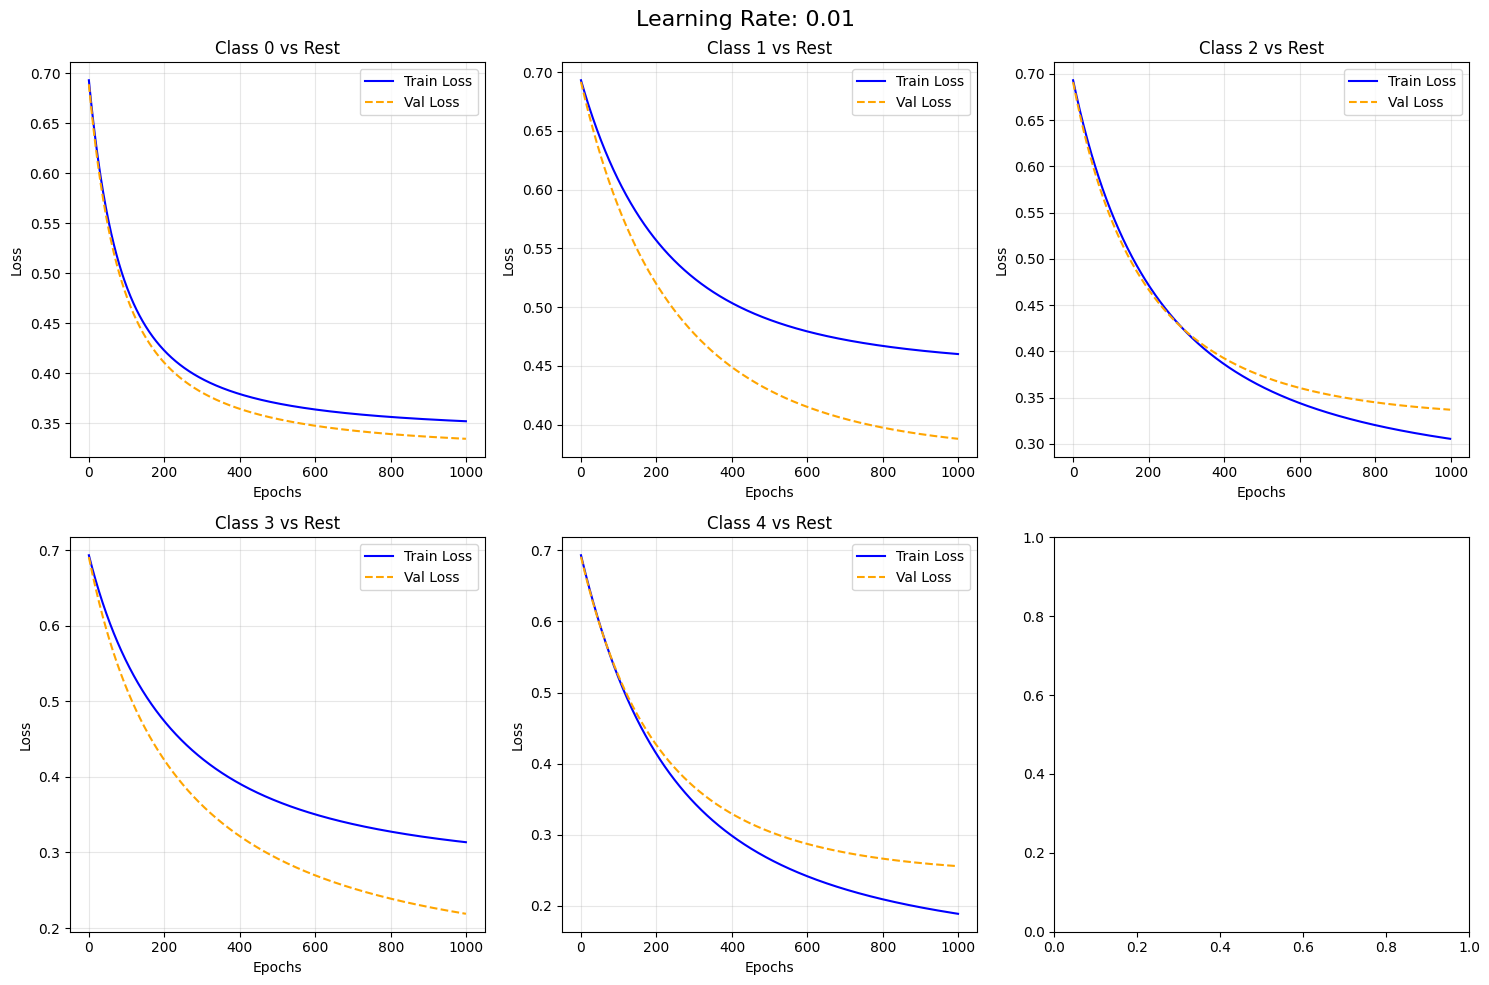

Training model for Class 0 vs Rest...
Training model for Class 1 vs Rest...
Early stopping triggered at epoch 173
Training model for Class 2 vs Rest...
Early stopping triggered at epoch 173
Training model for Class 3 vs Rest...
Training model for Class 4 vs Rest...
Early stopping triggered at epoch 157
0.1        | 501.2                          | 61.29%


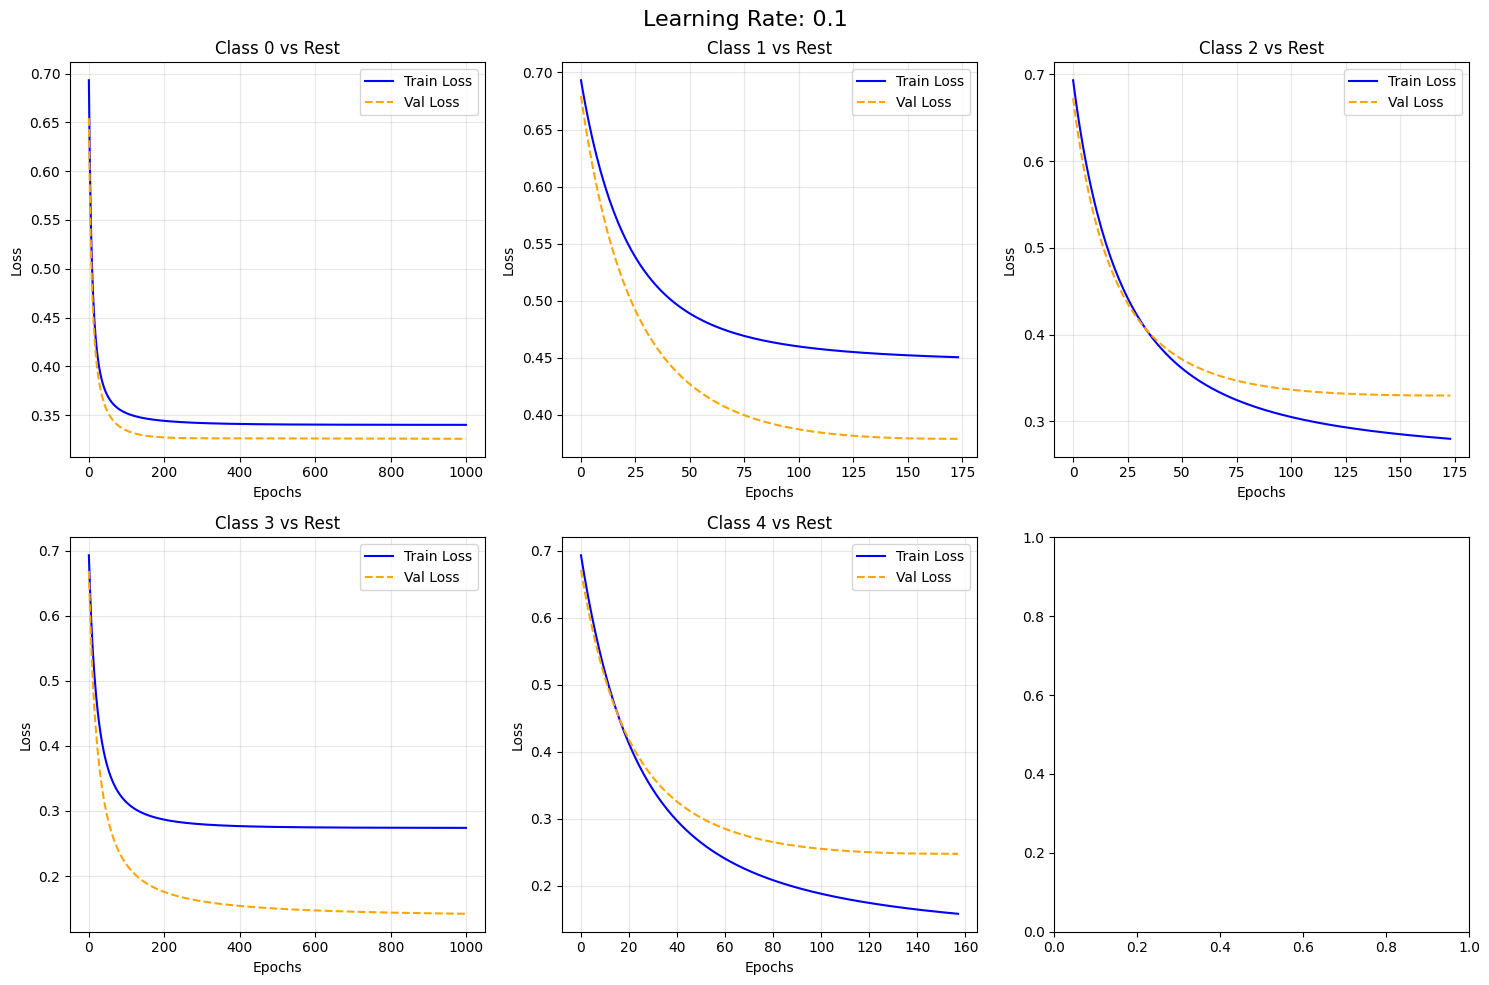

------------------------------------------------------------
Best Learning Rate: 0.01


In [161]:
print("\nTraining One-vs-Rest:")
print(f"{'LR':<10} | {'Avg Epochs':<15} | {'Accuracy':<10}")
print("-" * 60)

learning_rates = [0.01, 0.1]
fixed_lambda = 0.1

results = {}

for lr in learning_rates:
    ovr_classifier = OneVsRestClassifier(learning_rate=lr,
                                         reg_lambda=fixed_lambda,
                                         patience=3,
                                         max_epochs=1000)

    ovr_classifier.fit(X_train, y_train, X_val, y_val)
    y_pred_ovr = ovr_classifier.predict(X_test)
    accuracy = np.mean(y_pred_ovr == y_test) * 100
    results[lr] = accuracy

    avg_epochs = np.mean([len(m.train_losses) for m in ovr_classifier.models])
    print(f"{lr:<10} | {avg_epochs:<30} | {accuracy:.2f}%")
    plot_learning_curves_ovr(ovr_classifier, lr)


print("-" * 60)
print("Best Learning Rate:", max(results, key=results.get))

In [162]:
class OneVsOneClassifier:
    def __init__(self, learning_rate=0.01, reg_lambda=0.1, max_epochs=1000, patience=3):
        self.lr = learning_rate
        self.reg_lambda = reg_lambda
        self.max_epochs = max_epochs
        self.patience = patience
        self.models = []
        self.classes = []


    def fit(self, X_train, y_train, X_val, y_val):
        self.classes = np.unique(y_train)
        n_classes = len(self.classes)
        self.models = []

        for i in range(n_classes):
            for j in range(i+1, n_classes):
                c1 = self.classes[i]
                c2 = self.classes[j]

                print(f"Training model for Class {c1} vs Class {c2}...")

                train_mask = (y_train == c1) | (y_train == c2)
                val_mask = (y_val == c1) | (y_val == c2)

                X_train_sub = X_train[train_mask]
                y_train_sub = y_train[train_mask]

                X_val_sub = X_val[val_mask]
                y_val_sub = y_val[val_mask]

                # c2 -> 1 ,  c1 -> 0
                y_train_bin = np.where(y_train_sub == c1, 0, 1)
                y_val_bin = np.where(y_val_sub == c1, 0, 1)

                model = LogisticRegression(
                    learning_rate=self.lr,
                    reg_lambda=self.reg_lambda,
                    max_epochs=self.max_epochs,
                    patience=self.patience
                )
                model.fit(X_train_sub, y_train_bin, X_val_sub, y_val_bin)

                self.models.append({
                    'model' : model,
                    'class_0' : c1,
                    'class_1' : c2
                })


    def predict(self, X):
        n_samples = X.shape[0]

        votes = np.zeros((n_samples, len(self.classes)))

        for item in self.models:
            model = item['model']
            c0 = item['class_0']
            c1 = item['class_1']

            probs = model.predict_prob(X)

            predictions = np.where(probs > 0.5, c1, c0)

            for idx, pred_class in enumerate(predictions):
                class_idx = np.where(self.classes == pred_class)[0][0]
                votes[idx, class_idx] += 1

        final_predictions = np.argmax(votes, axis=1)
        return self.classes[final_predictions]


In [ ]:
def plot_learning_curves_ovo(ovo_model, lr):

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f'LR: {lr})', fontsize=16)
    
    axes = axes.flatten()
    
    for i, item in enumerate(ovo_model.models):
        actual_model = item['model'] 
        c1 = item['class_0']
        c2 = item['class_1']

        ax = axes[i]
        ax.plot(actual_model.train_losses, label='Train', color='blue')
        ax.plot(actual_model.val_losses, label='Val', color='orange', linestyle='--')
        
        ax.set_title(f'Class {c1} vs Class {c2}')
        ax.set_xlabel('Epochs')
        ax.set_ylabel('Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()


Training One-vs-One:
LR         | Avg Epochs      | Accuracy  
------------------------------------------------------------
Training model for Class 0 vs Class 1...
Training model for Class 0 vs Class 2...
Training model for Class 0 vs Class 3...
Training model for Class 0 vs Class 4...
Training model for Class 1 vs Class 2...
Early stopping triggered at epoch 190
Training model for Class 1 vs Class 3...
Training model for Class 1 vs Class 4...
Early stopping triggered at epoch 6
Training model for Class 2 vs Class 3...
Early stopping triggered at epoch 57
Training model for Class 2 vs Class 4...
Early stopping triggered at epoch 201
Training model for Class 3 vs Class 4...
Early stopping triggered at epoch 23
0.01       | 548.2           | 61.29%


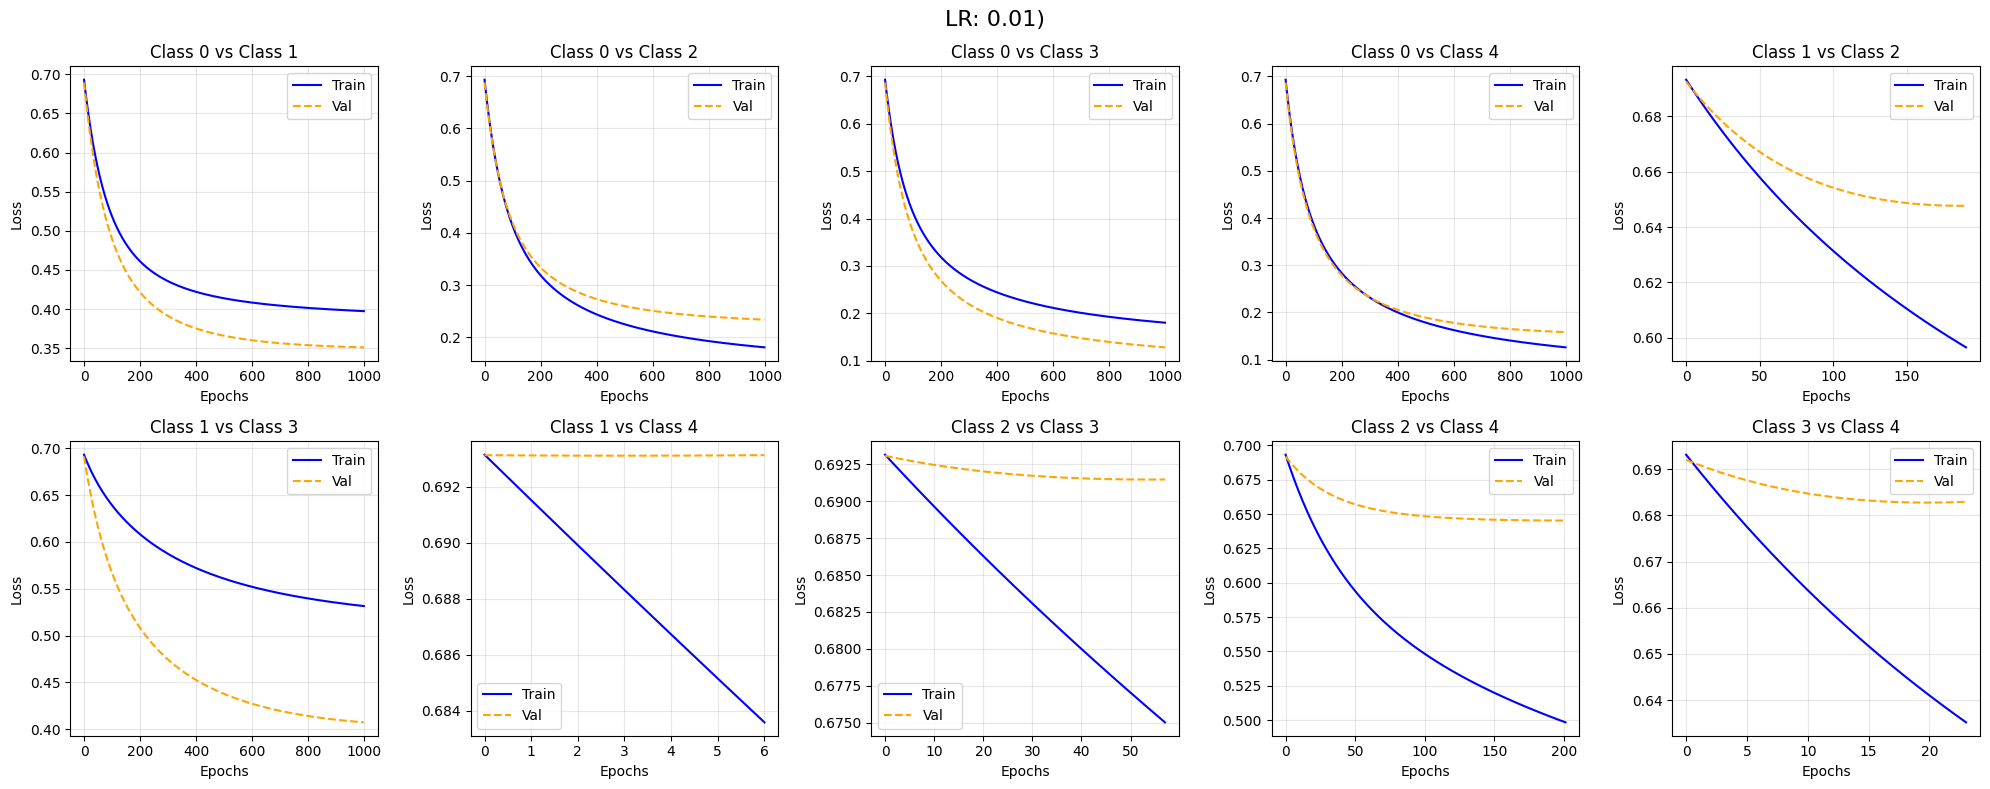

Training model for Class 0 vs Class 1...
Early stopping triggered at epoch 150
Training model for Class 0 vs Class 2...
Early stopping triggered at epoch 210
Training model for Class 0 vs Class 3...
Early stopping triggered at epoch 518
Training model for Class 0 vs Class 4...
Early stopping triggered at epoch 150
Training model for Class 1 vs Class 2...
Early stopping triggered at epoch 21
Training model for Class 1 vs Class 3...
Early stopping triggered at epoch 145
Training model for Class 1 vs Class 4...
Early stopping triggered at epoch 3
Training model for Class 2 vs Class 3...
Early stopping triggered at epoch 7
Training model for Class 2 vs Class 4...
Early stopping triggered at epoch 22
Training model for Class 3 vs Class 4...
Early stopping triggered at epoch 4
0.1        | 548.2           | 58.06%


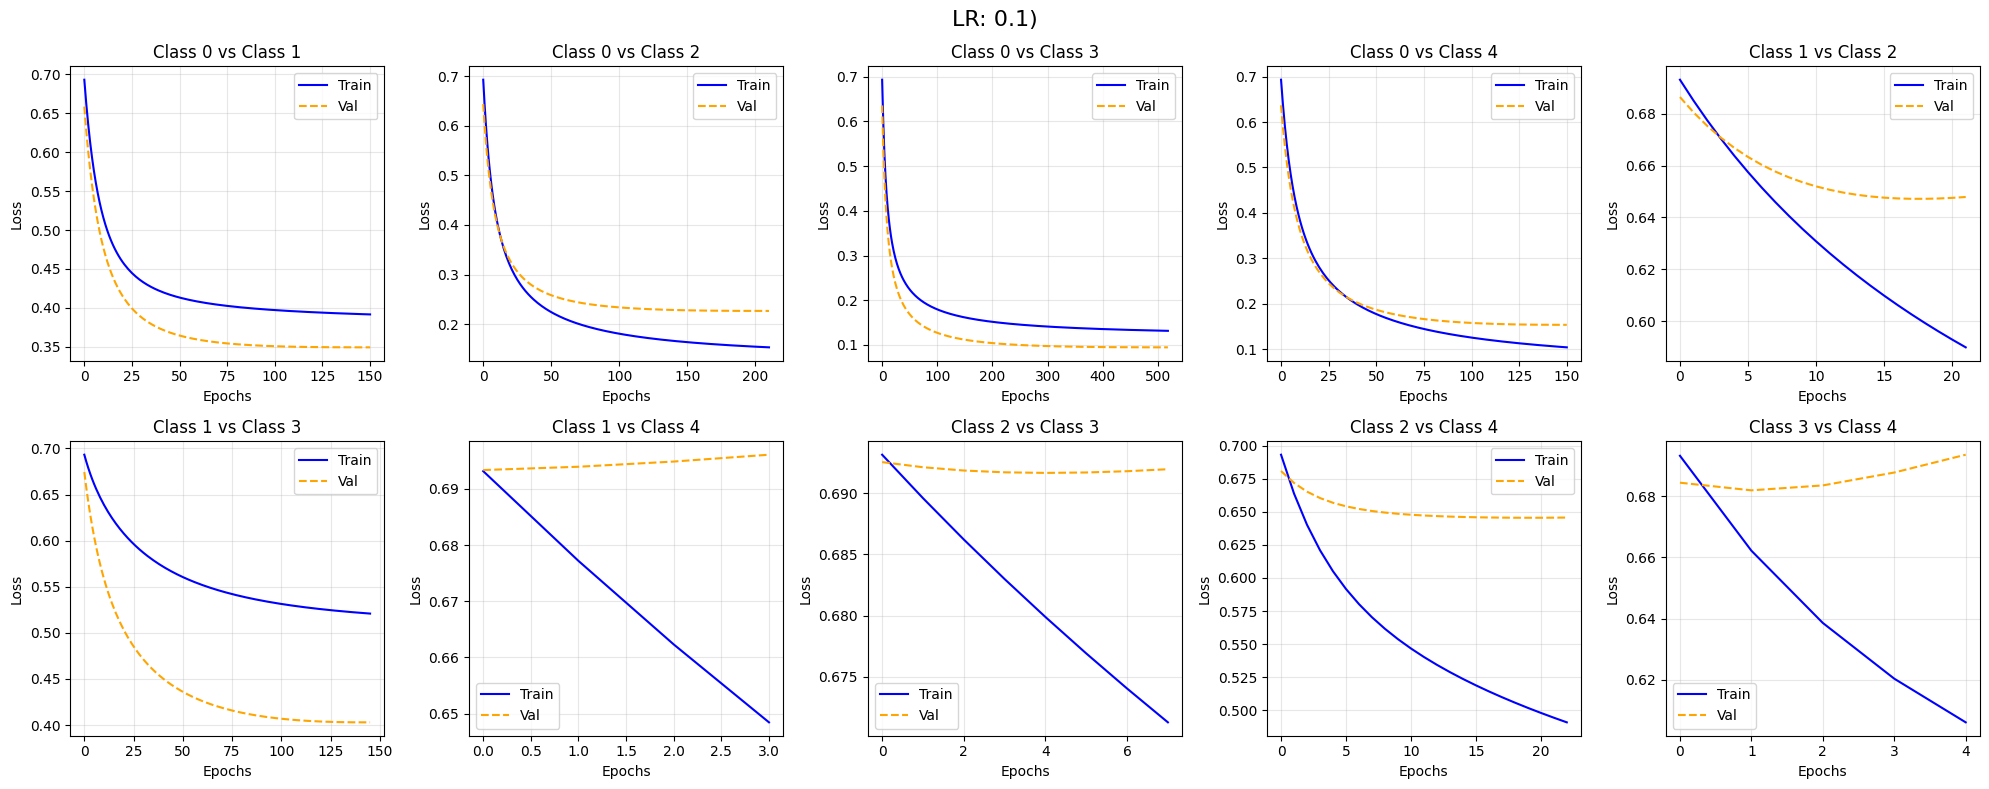

------------------------------------------------------------
Best OvO Learning Rate: 0.01


In [164]:
print("\nTraining One-vs-One:")

learning_rates = [0.01, 0.1]
fixed_lambda = 0.1

results_ovo = {}

print(f"{'LR':<10} | {'Avg Epochs':<15} | {'Accuracy':<10}")
print("-" * 60)

for lr in learning_rates:
    ovo_classifier = OneVsOneClassifier(
        learning_rate=lr,
        reg_lambda=fixed_lambda,
        patience=3,
        max_epochs=1000)
    
    ovo_classifier.fit(X_train, y_train, X_val, y_val)

    y_pred_ovo = ovo_classifier.predict(X_test)
    acc = np.mean(y_pred_ovo == y_test) * 100
    results_ovo[lr] = acc

    avg_epochs = np.mean([len(m['model'].train_losses) for m in ovo.models])

    print(f"{lr:<10} | {avg_epochs:<15.1f} | {acc:.2f}%")

    plot_learning_curves_ovo(ovo_classifier, lr)

print("-" * 60)
print("Best OvO Learning Rate:", max(results_ovo, key=results_ovo.get))

In [168]:
def ovr_uncertainty(ovr_model, X_test, y_test, threshold=0.05):
    print(f"\n🔍 OvR Uncertainty Analysis (Threshold < {threshold})")
    print("-" * 60)
    print(f"{'Sample ID':<10} | {'True Class':<12} | {'Top 2 Predictions (Class: Prob)':<35}")
    
    all_probs = []
    for model in ovr_model.models:
        prob = model.predict_prob(X_test) 
        all_probs.append(prob)
    
    all_probs = np.array(all_probs).T
    
    uncertain_count = 0
    
    for i in range(len(X_test)):
        probs = all_probs[i]
        
        sorted_indices = np.argsort(probs)[::-1]
        
        top1_idx = sorted_indices[0]
        top2_idx = sorted_indices[1]
        
        prob1 = probs[top1_idx]
        prob2 = probs[top2_idx]
        
        diff = prob1 - prob2
        
        if diff < threshold:
            uncertain_count += 1
            info = f"1st: C{ovr_model.classes[top1_idx]} ({prob1:.3f}) | 2nd: C{ovr_model.classes[top2_idx]} ({prob2:.3f})"
            print(f"{i:<10} | {y_test[i]:<12} | {info}")

    if uncertain_count == 0:
        print("No uncertain samples found.")
    else:
        print(f"\nTotal uncertain samples found: {uncertain_count}")

ovr_uncertainty(ovr_classifier, X_test, y_test, threshold=0.05)



🔍 OvR Uncertainty Analysis (Threshold < 0.05)
------------------------------------------------------------
Sample ID  | True Class   | Top 2 Predictions (Class: Prob)    
1          | 1            | 1st: C1 (0.308) | 2nd: C2 (0.293)
3          | 4            | 1st: C1 (0.324) | 2nd: C3 (0.287)
10         | 3            | 1st: C1 (0.334) | 2nd: C3 (0.334)
26         | 1            | 1st: C1 (0.364) | 2nd: C0 (0.354)
29         | 1            | 1st: C1 (0.366) | 2nd: C3 (0.333)

Total uncertain samples found: 5


In [171]:
def ovo_uncertainty(ovo_model, X_test, y_test, margin_threshold=2):
    print(f"{'ID':<5} | {'True':<5} | {'Winner':<8} | {'Runner-up':<10} | {'Margin':<6} | {'All Votes'}")
    
    n_samples = X_test.shape[0]
    classes = ovo_model.classes
    votes = np.zeros((n_samples, len(classes)))

    for item in ovo_model.models:
        model = item['model']
        c0 = item['class_0']
        c1 = item['class_1']
        
        probs = model.predict_prob(X_test)
        predictions = np.where(probs > 0.5, c1, c0)
        
        for idx, pred_class in enumerate(predictions):
            class_idx = np.where(classes == pred_class)[0][0]
            votes[idx, class_idx] += 1
            
    uncertain_count = 0
    
    for i in range(n_samples):
        sample_votes = votes[i]
        
        sorted_indices = np.argsort(sample_votes)[::-1]
        
        top1_idx = sorted_indices[0]
        top2_idx = sorted_indices[1]
        
        votes1 = sample_votes[top1_idx]
        votes2 = sample_votes[top2_idx]
        
        margin = votes1 - votes2
        
        if margin < margin_threshold:
            uncertain_count += 1
            
            winner_cls = classes[top1_idx]
            runner_cls = classes[top2_idx]
            true_cls = y_test[i]
            
            votes_dict = {classes[k]: int(v) for k, v in enumerate(sample_votes) if v > 0}
            
            print(f"{i:<5} | {true_cls:<5} | {winner_cls:<8} | {runner_cls:<10} | {margin:<6} | {votes_dict}")

    if uncertain_count == 0:
        print("No uncertain samples found.")
    else:
        print(f"\nTotal uncertain samples found: {uncertain_count}")

ovo_uncertainty(ovo_classifier, X_test, y_test, margin_threshold=2)


ID    | True  | Winner   | Runner-up  | Margin | All Votes
0     | 2     | 0        | 1          | 1.0    | {np.int64(0): 4, np.int64(1): 3, np.int64(3): 2, np.int64(4): 1}
1     | 1     | 2        | 1          | 1.0    | {np.int64(1): 3, np.int64(2): 4, np.int64(3): 2, np.int64(4): 1}
2     | 0     | 0        | 1          | 1.0    | {np.int64(0): 4, np.int64(1): 3, np.int64(2): 1, np.int64(4): 2}
3     | 4     | 3        | 1          | 1.0    | {np.int64(1): 3, np.int64(2): 2, np.int64(3): 4, np.int64(4): 1}
4     | 2     | 3        | 2          | 1.0    | {np.int64(1): 2, np.int64(2): 3, np.int64(3): 4, np.int64(4): 1}
5     | 1     | 0        | 1          | 1.0    | {np.int64(0): 4, np.int64(1): 3, np.int64(3): 1, np.int64(4): 2}
6     | 2     | 1        | 3          | 1.0    | {np.int64(1): 4, np.int64(2): 2, np.int64(3): 3, np.int64(4): 1}
7     | 0     | 0        | 1          | 1.0    | {np.int64(0): 4, np.int64(1): 3, np.int64(3): 1, np.int64(4): 2}
8     | 0     | 1        | 0 

In [176]:
def plot_confusion_matrix(y_true, y_pred, model):
    classes = np.unique(np.concatenate((y_true, y_pred)))
    n_classes = len(classes)
    
    cm = np.zeros((n_classes, n_classes), dtype=int)
    
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    
    fig, ax = plt.subplots()
    cax = ax.matshow(cm, cmap='Blues')
    plt.title(f'Confusion Matrix {model}')
    fig.colorbar(cax)
    
    for (i, j), z in np.ndenumerate(cm):
        color = 'white' if z > cm.max()/2 else 'black'
        ax.text(j, i, str(z), ha='center', va='center', color=color)
    
    plt.xlabel('Predicted')
    plt.ylabel('True')
    
    ax.set_xticks(np.arange(n_classes))
    ax.set_yticks(np.arange(n_classes))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    
    plt.show()

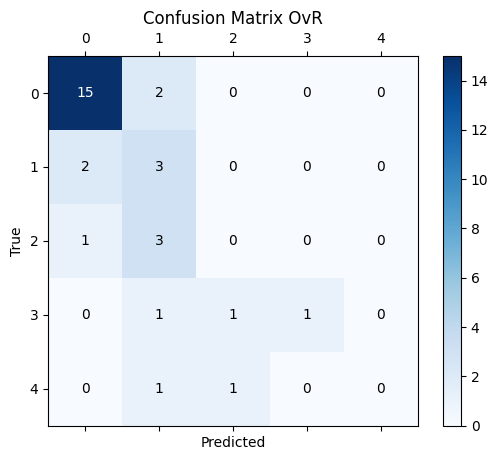

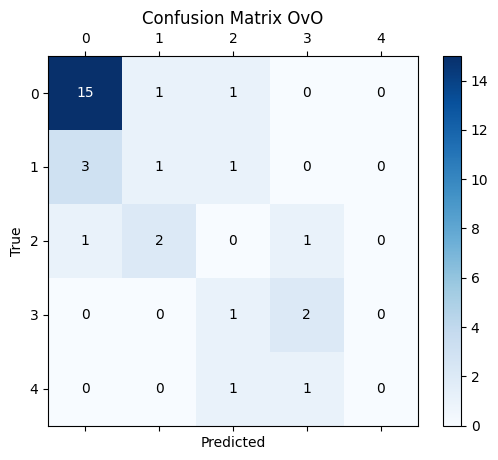

In [177]:
plot_confusion_matrix(y_test, y_pred_ovr, 'OvR')
plot_confusion_matrix(y_test, y_pred_ovo, 'OvO')